In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from tmrl.envs import GenericGymEnv
from tmrl.config.config_objects import CONFIG_DICT
import torch.distributions as dist
from collections import deque
import random
import matplotlib.pyplot as plt
import os

In [2]:
os.makedirs("pesos_trackmania", exist_ok=True)

In [3]:
env = GenericGymEnv(id="real-time-gym-ts-v1", gym_kwargs={"config": CONFIG_DICT})

c:\Users\andre\AppData\Local\Programs\Python\Python313\Lib\site-packages\rtgym\envs\real_time_env.py:662: UserWarning: Time-step timed out. Elapsed since last time-step: 1.034813900012523
  warnings.warn(f"Time-step timed out. Elapsed since last time-step: {now - self.__t_end}")
c:\Users\andre\AppData\Local\Programs\Python\Python313\Lib\site-packages\rtgym\envs\real_time_env.py:662: UserWarning: Time-step timed out. Elapsed since last time-step: 0.32479190002777614
  warnings.warn(f"Time-step timed out. Elapsed since last time-step: {now - self.__t_end}")
c:\Users\andre\AppData\Local\Programs\Python\Python313\Lib\site-packages\rtgym\envs\real_time_env.py:662: UserWarning: Time-step timed out. Elapsed since last time-step: 0.10710580000886694
  warnings.warn(f"Time-step timed out. Elapsed since last time-step: {now - self.__t_end}")
c:\Users\andre\AppData\Local\Programs\Python\Python313\Lib\site-packages\rtgym\envs\real_time_env.py:662: UserWarning: Time-step timed out. Elapsed since la

In [4]:
TAMANHO_MEMORIA = 50000     # Memória maior para não esquecer o passado rápido
TAMANHO_BATCH = 128         # Lotes maiores para estabilizar o gradiente da placa de vídeo
MAX_EPISODIOS = 5000        # Deixando um limite bem alto para o treino autônomo
MAX_PASSOS_POR_EPISODIO = 5000
gamma = 0.99

memoria = deque(maxlen=TAMANHO_MEMORIA)

In [5]:
TAMANHO_INPUT = 83 # 1 (vel) + 19 (lidar) + 6 (histórico de ações)
TAMANHO_OUTPUT = 3 # Acelerar, Frear, Virar

In [6]:
historico_recompensas = []
historico_loss_ator = []
historico_loss_critico = []

In [7]:
class Ator(nn.Module):
    def __init__(self):
        super(Ator, self).__init__()
        self.rede = nn.Sequential(
            nn.Linear(TAMANHO_INPUT, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, TAMANHO_OUTPUT),
            nn.Tanh()
        )

    def forward(self, x):
        return self.rede(x)

In [8]:
class Critico(nn.Module):
    def __init__(self):
        super(Critico, self).__init__()
        self.rede = nn.Sequential(
            nn.Linear(TAMANHO_INPUT, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.rede(x)

In [9]:
ator = Ator()
critico = Critico()

In [10]:
otimizador_ator = optim.Adam(ator.parameters(), lr=0.00005) 
otimizador_critico = optim.Adam(critico.parameters(), lr=0.0005)

### Carregar pesos se houver

In [11]:
ator.load_state_dict(torch.load("pesos_trackmania/ator_ep100.pth"))
critico.load_state_dict(torch.load("pesos_trackmania/critico_ep100.pth"))
print("Pesos carregados com sucesso. Retomando o treinamento...")

Pesos carregados com sucesso. Retomando o treinamento...


In [12]:
print("Dando o play na pista... CLIQUE NA JANELA DO JOGO AGORA!")

try:
    for episodio in range(MAX_EPISODIOS):
        obs, info = env.reset()
        recompensa_ep = 0
        loss_ator_ep = []
        loss_critico_ep = []

        for passo in range(MAX_PASSOS_POR_EPISODIO):
            # 1. PREPARAÇÃO DO ESTADO ATUAL
            velocidade = np.array(obs[0]).flatten()
            lidar = np.array(obs[1]).flatten()
            acoes = [np.array(a).flatten() for a in obs[2:]]
            historico_acoes = np.concatenate(acoes) if len(acoes) > 0 else np.array([])
            
            estado_atual = np.concatenate([velocidade, lidar, historico_acoes])
            estado_tensor = torch.tensor(estado_atual, dtype=torch.float32)
            
            # 2. O ATOR AGE (SEM TREINAR)
            with torch.no_grad():
                mu = ator(estado_tensor)
                
                # ADICIONE OS EPISÓDIOS DO PASSADO AQUI! (Ex: +100)
                episodio_real = episodio + 100 
                ruido_atual = max(0.05, 0.4 * (0.995 ** episodio_real))
                
                std = torch.ones_like(mu) * ruido_atual
                distribuicao = dist.Normal(mu, std)
                acao = distribuicao.sample()
                acao = torch.clamp(acao, -1.0, 1.0)
                
            # 3. INTERAÇÃO COM O JOGO
            acao_numpy = acao.numpy()
            proximo_obs, recompensa_crua, terminated, truncated, info = env.step(acao_numpy)
            done = terminated or truncated

            # REWARD SHAPING
            recompensa = recompensa_crua
            velocidade_kmh = proximo_obs[0][0]
            
            # Punição por lentidão mais suave
            #if velocidade_kmh < 5.0:
            #    recompensa -= 0.1
                
            if recompensa_crua > 0:
                recompensa += (velocidade_kmh * 0.01)
            
            # Punição capital por bater de frente / sair da pista
            #if done and recompensa_crua < 50.0:
            #    recompensa -= 50.0
                
            # Punição por raspar na parede usando o Lidar (raios)
            #lidar_recente = proximo_obs[1][-1] 
            #menor_distancia = np.min(lidar_recente)
            
            #if menor_distancia < 0.08 and not done:
            #    recompensa -= 1.0
                
            recompensa_ep += recompensa

            # PREPARAÇÃO DO PRÓXIMO ESTADO
            prox_velocidade = np.array(proximo_obs[0]).flatten()
            prox_lidar = np.array(proximo_obs[1]).flatten()
            prox_acoes = [np.array(a).flatten() for a in proximo_obs[2:]]
            prox_historico = np.concatenate(prox_acoes) if len(prox_acoes) > 0 else np.array([])
            
            proximo_estado = np.concatenate([prox_velocidade, prox_lidar, prox_historico])
            
            # 4. SALVANDO NA MEMÓRIA
            memoria.append((estado_atual, acao_numpy, recompensa, proximo_estado, int(done)))

            # 5. TREINAMENTO EM LOTE
            if len(memoria) >= 1000:
                lote = random.sample(memoria, TAMANHO_BATCH)
                
                estados_b = torch.tensor(np.array([exp[0] for exp in lote]), dtype=torch.float32)
                acoes_b = torch.tensor(np.array([exp[1] for exp in lote]), dtype=torch.float32)
                recompensas_b = torch.tensor(np.array([exp[2] for exp in lote]), dtype=torch.float32)
                prox_estados_b = torch.tensor(np.array([exp[3] for exp in lote]), dtype=torch.float32)
                dones_b = torch.tensor(np.array([exp[4] for exp in lote]), dtype=torch.float32)

                # Avaliando o lote inteiro
                mu_b = ator(estados_b)
                
                # CORREÇÃO CRÍTICA: O lote também precisa usar o ruído atual!
                std_b = torch.ones_like(mu_b) * ruido_atual
                dist_b = dist.Normal(mu_b, std_b)
                
                log_probs_b = dist_b.log_prob(acoes_b).sum(dim=1)
                
                valores_atuais_b = critico(estados_b).squeeze()
                with torch.no_grad():
                    valores_proximos_b = critico(prox_estados_b).squeeze()
                    
                # 1. Calculamos o Advantage "Cru" (O erro real)
                advantage_b = recompensas_b + (gamma * valores_proximos_b * (1 - dones_b)) - valores_atuais_b
                
                # 2. Loss do Crítico usa o erro REAL (antes de normalizar)
                loss_critico = advantage_b.pow(2).mean()
                
                # 3. Estabilizador de Voo: Normalizamos APENAS para o Ator
                advantage_norm = (advantage_b - advantage_b.mean()) / (advantage_b.std() + 1e-8)
                
                # 4. Loss do Ator usa a versão estabilizada
                loss_ator = (-log_probs_b * advantage_norm.detach()).mean()

                otimizador_ator.zero_grad()
                loss_ator.backward()
                # Trava de segurança para o Loss não explodir
                torch.nn.utils.clip_grad_norm_(ator.parameters(), max_norm=1.0)
                otimizador_ator.step()
                
                otimizador_critico.zero_grad()
                loss_critico.backward()
                # Trava de segurança para o Crítico
                torch.nn.utils.clip_grad_norm_(critico.parameters(), max_norm=1.0)
                otimizador_critico.step()

                loss_ator_ep.append(loss_ator.item())
                loss_critico_ep.append(loss_critico.item())

            if done:
                break
            else:
                obs = proximo_obs

        # --- FIM DO EPISÓDIO ---
        historico_recompensas.append(recompensa_ep)
        media_loss_ator = np.mean(loss_ator_ep) if len(loss_ator_ep) > 0 else 0
        media_loss_critico = np.mean(loss_critico_ep) if len(loss_critico_ep) > 0 else 0
        
        historico_loss_ator.append(media_loss_ator)
        historico_loss_critico.append(media_loss_critico)
        
        print(f"Episódio {episodio+1}/{MAX_EPISODIOS} | Passos: {passo+1} | Recompensa Total: {recompensa_ep:.1f} | Loss Ator: {media_loss_ator:.4f} | Loss Crítico: {media_loss_critico:.4f}")

        # Salva o progresso a cada 10 episódios
        if (episodio + 1) % 100 == 0:
            torch.save(ator.state_dict(), f"pesos_trackmania/ator_ep{episodio+1}.pth")
            torch.save(critico.state_dict(), f"pesos_trackmania/critico_ep{episodio+1}.pth")
            print("Pesos parciais salvos!")

except KeyboardInterrupt:
    print("\nTreinamento interrompido manualmente")

finally:
    print("Salvando pesos finais e gerando gráficos...")
    torch.save(ator.state_dict(), "pesos_trackmania/ator_FINAL.pth")
    torch.save(critico.state_dict(), "pesos_trackmania/critico_FINAL.pth")

Dando o play na pista... CLIQUE NA JANELA DO JOGO AGORA!
Episódio 1/5000 | Passos: 123 | Recompensa Total: 23.7 | Loss Ator: 0.0000 | Loss Crítico: 0.0000
Episódio 2/5000 | Passos: 528 | Recompensa Total: 115.4 | Loss Ator: 0.0000 | Loss Crítico: 0.0000
Episódio 3/5000 | Passos: 605 | Recompensa Total: 113.7 | Loss Ator: -0.1570 | Loss Crítico: 0.6138
Episódio 4/5000 | Passos: 120 | Recompensa Total: 25.8 | Loss Ator: -0.3069 | Loss Crítico: 0.6930
Episódio 5/5000 | Passos: 729 | Recompensa Total: 197.4 | Loss Ator: -0.5357 | Loss Crítico: 0.6524
Episódio 6/5000 | Passos: 805 | Recompensa Total: 211.3 | Loss Ator: -0.6422 | Loss Crítico: 0.7244
Episódio 7/5000 | Passos: 821 | Recompensa Total: 216.4 | Loss Ator: -0.6031 | Loss Crítico: 0.8451
Episódio 8/5000 | Passos: 560 | Recompensa Total: 163.6 | Loss Ator: -0.5036 | Loss Crítico: 0.8585
Episódio 9/5000 | Passos: 81 | Recompensa Total: 14.9 | Loss Ator: -0.5714 | Loss Crítico: 0.8026
Episódio 10/5000 | Passos: 743 | Recompensa Total

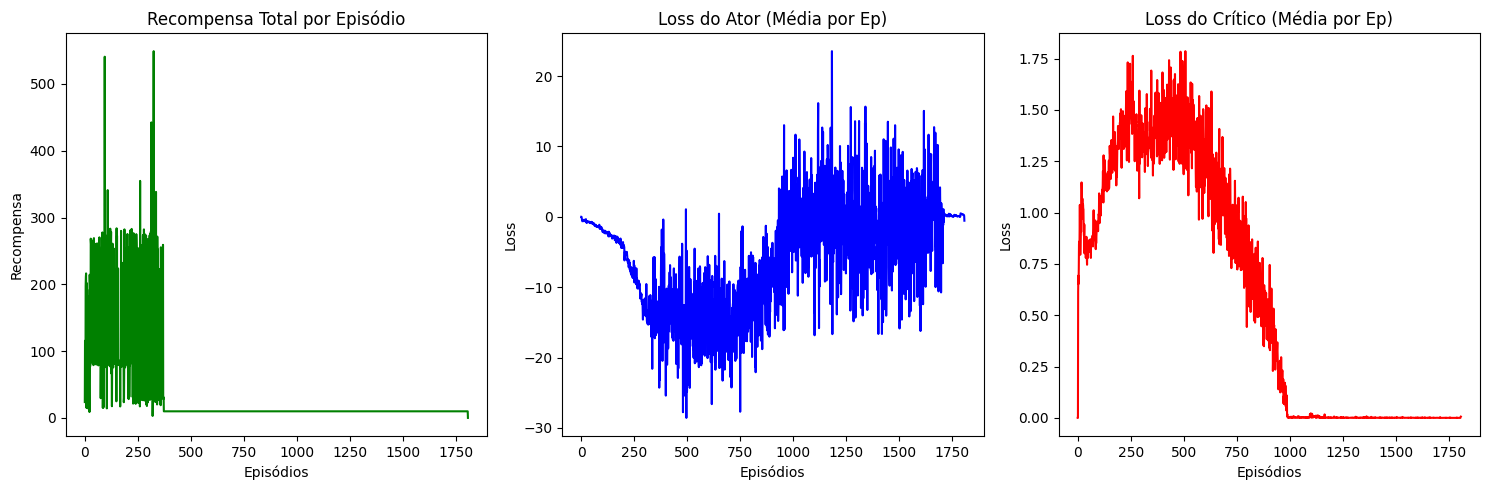

In [16]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(historico_recompensas, color='green')
plt.title('Recompensa Total por Episódio')
plt.xlabel('Episódios')
plt.ylabel('Recompensa')

plt.subplot(1, 3, 2)
plt.plot(historico_loss_ator, color='blue')
plt.title('Loss do Ator (Média por Ep)')
plt.xlabel('Episódios')
plt.ylabel('Loss')

plt.subplot(1, 3, 3)
plt.plot(historico_loss_critico, color='red')
plt.title('Loss do Crítico (Média por Ep)')
plt.xlabel('Episódios')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()